# Game-Isolated Model Validation

## tl;dr

- The primary demonstration model holds out the latest complete games, never individual pitch rows.
- Using the deterministic sample and scikit-learn backend, holdout MAE is approximately 0.41 mph.
- The model improves on a train-mean baseline by approximately 21%, with holdout R² near 0.42.
- Feature importance is associative and must not be described as causal.

## Context & Methods

This notebook validates the model boundary that matters most: every pitch from a
test game is unseen during training. The primary model uses only pre-pitch
context. A separate descriptive-quality model supplies feature importance and
may include same-pitch tracking measurements.

### Key Assumptions

- The latest 20% of games form the chronological holdout.
- Mean absolute error is the primary accuracy measure because its unit is mph.
- A train-mean predictor is the explicit naive benchmark.
- Same-game pitch rows are dependent, so MAE uncertainty resamples games.

## Data

### 1. Build the validated feature table

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from pitcher_fatigue.config import AnalysisConfig
from pitcher_fatigue.features import build_features
from pitcher_fatigue.model import (
    compute_feature_importance,
    train_velocity_model,
)
from pitcher_fatigue.quality import validate_and_clean_statcast

raw = pd.read_csv(ROOT / "data" / "sample" / "sample_pitcher.csv", low_memory=False)
config = AnalysisConfig()
cleaned, quality = validate_and_clean_statcast(raw, config)
features = build_features(cleaned, config)
features.shape

(1661, 42)

## Results

### 2. Train on complete earlier games

In [2]:
pre_pitch_model = train_velocity_model(
    features,
    feature_mode="pre_pitch",
    backend="sklearn",
    split_strategy="chronological",
    cross_validate=True,
    config=config,
)
pd.Series(pre_pitch_model.metrics)

mae                         0.406428
mae_ci_lower                0.375125
mae_ci_upper                0.436439
rmse                        0.511873
r2                          0.414574
naive_mae                   0.514357
mae_improvement_pct        20.983286
train_games                       12
test_games                         4
train_pitches                   1234
test_pitches                     427
split_strategy         chronological
group_cv_folds                     5
group_cv_mae_mean           0.428662
group_cv_mae_sd             0.014202
dtype: object

### 3. Audit the game boundary

In [3]:
split_audit = pd.DataFrame(
    {
        "partition": (
            ["train"] * len(pre_pitch_model.split.train_games)
            + ["test"] * len(pre_pitch_model.split.test_games)
        ),
        "game_pk": (
            list(pre_pitch_model.split.train_games)
            + list(pre_pitch_model.split.test_games)
        ),
    }
)
assert set(pre_pitch_model.split.train_games).isdisjoint(
    pre_pitch_model.split.test_games
)
split_audit

,partition,game_pk
0,train,900000
1,train,900001
2,train,900002
3,train,900003
4,train,900004
5,train,900005
6,train,900006
7,train,900007
8,train,900008
9,train,900009


### 4. Inspect held-out predictions

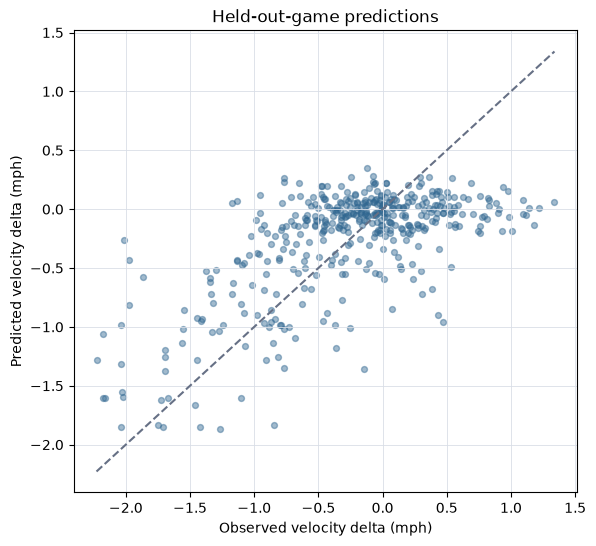

In [4]:
prediction = pre_pitch_model.prediction_frame()
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(
    prediction["actual_speed_delta"],
    prediction["predicted_speed_delta"],
    color="#2F6690",
    alpha=0.45,
    s=18,
)
lower = min(
    prediction["actual_speed_delta"].min(),
    prediction["predicted_speed_delta"].min(),
)
upper = max(
    prediction["actual_speed_delta"].max(),
    prediction["predicted_speed_delta"].max(),
)
ax.plot([lower, upper], [lower, upper], color="#667085", linestyle="--")
ax.set(
    title="Held-out-game predictions",
    xlabel="Observed velocity delta (mph)",
    ylabel="Predicted velocity delta (mph)",
)
ax.grid(color="#D9DEE7", linewidth=0.6)
plt.show()

### 5. Explain the descriptive-quality model

In [5]:
descriptive_model = train_velocity_model(
    features,
    feature_mode="descriptive_quality",
    backend="sklearn",
    split_strategy="chronological",
    cross_validate=False,
    config=config,
)
importance, method = compute_feature_importance(
    descriptive_model,
    prefer_shap=True,
    random_state=config.random_state,
)
importance

,feature,importance,importance_sd,share
0,game_pitch_count,0.170787,0.009258,0.859760
1,pitch_type,0.027238,0.007936,0.137118
2,stand,0.000620,0.000846,0.003122
3,inning,0.000000,0.000000,0.000000
4,n_thruorder_pitcher,0.000000,0.000000,0.000000
5,pitcher_days_since_prev_game,0.000000,0.000000,0.000000
6,spin_delta_rpm,0.000000,0.002783,0.000000
7,extension_delta_ft,0.000000,0.005100,0.000000
8,pfx_x_delta_in,0.000000,0.005186,0.000000
9,pfx_z_delta_in,0.000000,0.003314,0.000000


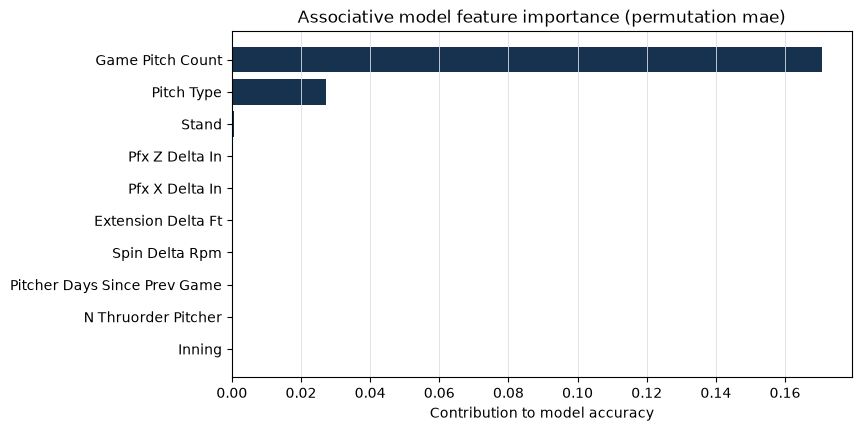

In [6]:
plot_data = importance.head(10).sort_values("importance")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(
    plot_data["feature"].str.replace("_", " ").str.title(),
    plot_data["importance"],
    color="#16324F",
)
ax.set(
    title=f"Associative model feature importance ({method.replace('_', ' ')})",
    xlabel="Contribution to model accuracy",
)
ax.grid(axis="x", color="#D9DEE7", linewidth=0.6)
plt.show()

## Takeaways

The train/test boundary is clean at the game level and the test period is later
than the training period. The synthetic benchmark is useful for regression
testing, not as a claim about MLB performance. Model importance describes what
the fitted model used; it does not show that a feature caused fatigue.